<a href="https://colab.research.google.com/github/eunjae333666/7.32/blob/main/7_32.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Problem 7.32.**

Although the integrals (7.53 and 7.54) for N and U cannot be
carried out analytically for all T, it’s not dicult to evaluate them numerically
using a computer. This calculation has little relevance for electrons in metals (for
which the limit $kT<<\epsilon_F$ is always sucient), but it is needed for liquid 3He and
for astrophysical systems like the electrons at the center of the sun.



---



##Dimensionless variable 사용

###(a)  
As a warm-up exercise, evaluate the N integral (7.53) for the case $kT=\epsilon_F$
and µ = 0, and check that your answer is consistent with the graph shown above. (Hint: As always when solving a problem on a computer, it’s best to
first put everything in terms of dimensionless variables. So let $t=\frac{kT}{\epsilon_F},$
$c=\frac{\mu}{\epsilon_F},$
$x=\frac{\epsilon}{\epsilon_F}$. Rewrite everything in terms of these variables,
and then put it on the computer.)


$
g(\epsilon)=g_0\sqrt{\epsilon},
\qquad
g_0=\frac{3N}{2\epsilon_F^{3/2}}.
$

<br>

위에 것을 대입하면,
<br>
<br>

$
N=\int_0^\infty g(\epsilon)
\frac{1}{e^{(\epsilon-\mu)/kT}+1}\,d\epsilon =
\frac{3N}{2}
\int_0^\infty
\frac{\sqrt{x}}
{e^{(x-c)/t}+1}\,dx
$  
<br>


양변을 N으로 나누면,   
<br>
$
1=
\frac32
\int_0^\infty
\frac{\sqrt{x}}
{e^{(x-c)/t}+1}\,dx
$  
<br>

특히 (a)의 상황에서는 $t=1, c=0$이다.

In [1]:
import numpy as np
from scipy.integrate import quad

# Problem 7.32(a)
t = 1.0                 # kT / epsilon_F
c = 0.0                 # mu / epsilon_F

def integrand(x):
    z = (x - c) / t

    # numerically stable evaluation for large z
    if z > 50:
        fermi = np.exp(-z)
    else:
        fermi = 1.0 / (np.exp(z) + 1.0)

    return np.sqrt(x) * fermi


I, error = quad(
    integrand,
    0,
    np.inf,
    epsabs=1e-12,
    epsrel=1e-12,
    limit=500
)

N_over_N0 = 1.5 * I

print("Integral =", I)
print("(3/2) Integral =", N_over_N0)
print("Estimated numerical error =", error)

Integral = 0.678093895153101
(3/2) Integral = 1.0171408427296516
Estimated numerical error = 7.528354552567296e-16


즉, $\frac{N_{calc}}{N}=1.017140...$  

N을 유지하기 위해서는 $kT=\epsilon_F$에서 $\mu$가 0보다 조금 더 작아야한다.



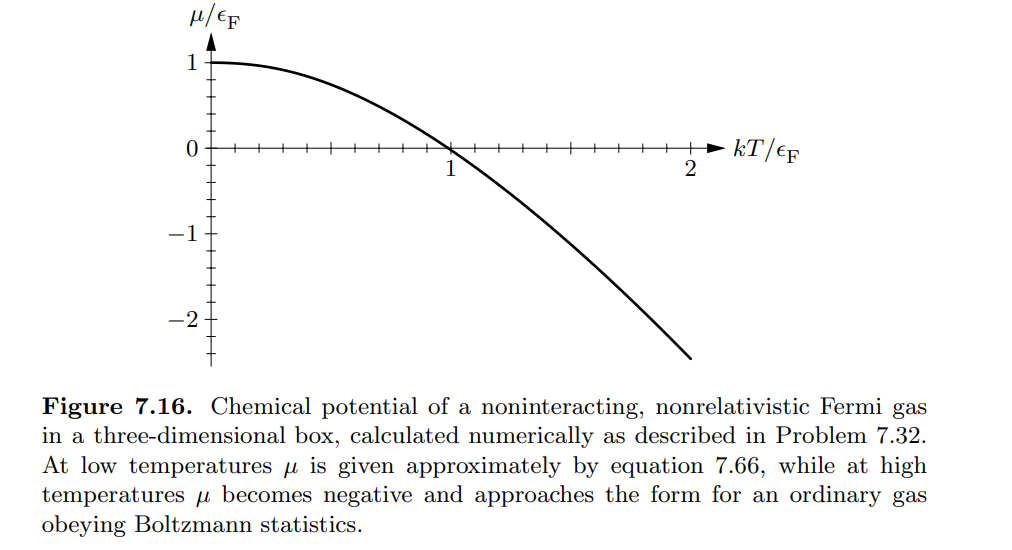



---



###(b)   
The next step is to vary $\mu$, holding $T$ fixed, until the integral works out to
the desired value, $N$. Do this for values of $kT/\epsilon_F$ ranging from 0.1 up to 2,
and plot the results to reproduce Figure 7.16. (It’s probably not a good idea
to try to use numerical methods when $kT/\epsilon_F$ is much smaller than $0.1$, since
you can start getting overflow errors from exponentiating large numbers.
But this is the region where we’ve already solved the problem analytically.)

exp 대신 expit(x)=$\frac{1}{(1+e^{-x})}$ 쓰면 0.1보다 작아도 안터짐

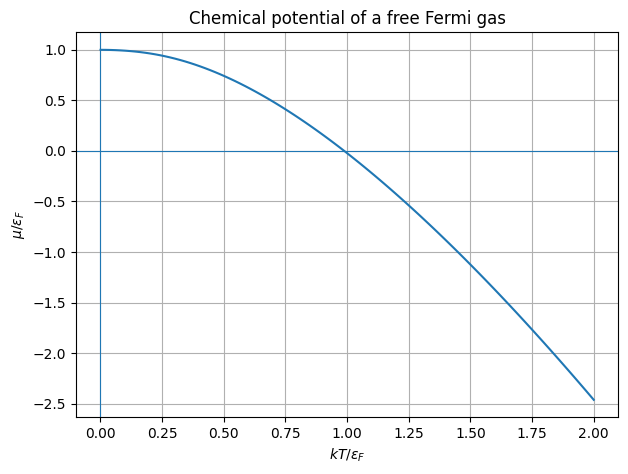

kT/epsilon_F = 0.001, mu/epsilon_F =  0.999999
kT/epsilon_F = 0.100, mu/epsilon_F =  0.991641
kT/epsilon_F = 0.500, mu/epsilon_F =  0.743112
kT/epsilon_F = 1.000, mu/epsilon_F = -0.021461
kT/epsilon_F = 2.000, mu/epsilon_F = -2.461439


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import quad
from scipy.optimize import brentq
from scipy.special import expit


def N_ratio(c, t):
    """
    Returns N_calculated / N
    for given c = mu/epsilon_F and t = kT/epsilon_F.
    """

    def integrand(x):
        # 1 / (exp((x-c)/t) + 1)
        f_FD = expit(-(x - c) / t)

        return 1.5 * np.sqrt(x) * f_FD

    value, error = quad(
        integrand,
        0.0,
        np.inf,
        epsabs=1e-10,
        epsrel=1e-10,
        limit=300
    )

    return value


def find_c(t):
    """
    Find c = mu/epsilon_F such that N_calculated / N = 1.
    """

    def equation(c):
        return N_ratio(c, t) - 1.0

    return brentq(equation, -20.0, 3.0)


# Temperatures requested in Problem 7.32(b)
min_T=0.001
t_values = np.linspace(min_T, 2.0, 100)

c_values = np.array([
    find_c(t)
    for t in t_values
])


plt.figure(figsize=(7, 5))

plt.plot(t_values, c_values)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel(r"$kT/\epsilon_F$")
plt.ylabel(r"$\mu/\epsilon_F$")
plt.title("Chemical potential of a free Fermi gas")

plt.grid()

plt.show()


# Some representative numerical values
for t in [min_T,0.1, 0.5, 1.0, 2.0]:
    print(
        f"kT/epsilon_F = {t:3.3f}, "
        f"mu/epsilon_F = {find_c(t): .6f}"
    )

###(c)   
Plug your calculated values of µ into the energy integral (7.54), and evaluate
that integral numerically to obtain the energy as a function of temperature
for $kT$ up to $2\epsilon_F$. Plot the results, and evaluate the slope to obtain the
heat capacity. Check that the heat capacity has the expected behavior at
both low and high temperatures.

$$
U=\int_0^\infty \epsilon\, g(\epsilon)\frac{1}{e^{(\epsilon-\mu)/kT}+1}d\epsilon =
\frac{3N\epsilon_F}{2}\int_0^\infty
\frac{x^{3/2}}{e^{(x-c)/t}+1}dx
$$


$$\frac{U}{N\epsilon_F}
=
\frac32
\int_0^\infty
\frac{x^{3/2}}{e^{(x-c)/t}+1}dx$$

$
C_V=\left(\frac{\partial U}{\partial T}\right)_V.
$  
<br>
dimensionless로 만들기 위해,
$
y=\frac{U}{N\epsilon_F}
$로 두면  
  

  <br>
$
\frac{dy}{dt}
=
\frac{C_V}{Nk_B}.
$

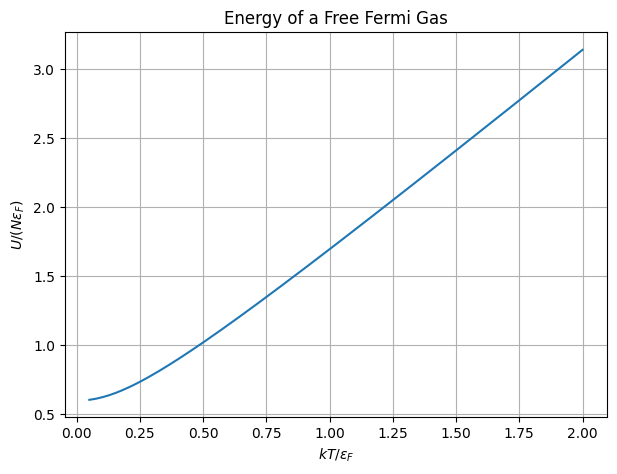

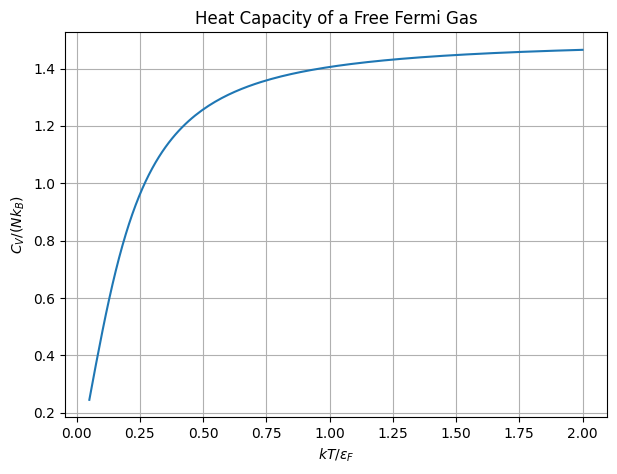

kT/epsilon_F = 0.1, mu/epsilon_F =  0.991641, U/(N epsilon_F) =  0.624283
kT/epsilon_F = 0.5, mu/epsilon_F =  0.743112, U/(N epsilon_F) =  1.021642
kT/epsilon_F = 1.0, mu/epsilon_F = -0.021461, U/(N epsilon_F) =  1.696739
kT/epsilon_F = 2.0, mu/epsilon_F = -2.461439, U/(N epsilon_F) =  3.140353


In [3]:
def U_ratio(c, t):
    """
    Returns U / (N * epsilon_F)
    """

    def integrand(x):
        f_FD = expit(-(x - c) / t)

        return (
            1.5
            * x**1.5
            * f_FD
        )

    value, error = quad(
        integrand,
        0.0,
        np.inf,
        epsabs=1e-10,
        epsrel=1e-10,
        limit=300
    )

    return value


# temperature range
t_values = np.linspace(0.05, 2.0, 150)

# chemical potential
c_values = np.array([
    find_c(t)
    for t in t_values
])

# energy
U_values = np.array([
    U_ratio(c, t)
    for c, t in zip(c_values, t_values)
])


# Since
# t = kT / epsilon_F
# and y = U / (N epsilon_F),
#
# dy/dt = C_V / (N k_B)

Cv_values = np.gradient(
    U_values,
    t_values,
    edge_order=2
)


# Plot energy
plt.figure(figsize=(7, 5))

plt.plot(t_values, U_values)

plt.xlabel(r"$kT/\epsilon_F$")
plt.ylabel(r"$U/(N\epsilon_F)$")
plt.title("Energy of a Free Fermi Gas")

plt.grid()
plt.show()


# Plot heat capacity
plt.figure(figsize=(7, 5))

plt.plot(t_values, Cv_values)

plt.xlabel(r"$kT/\epsilon_F$")
plt.ylabel(r"$C_V/(Nk_B)$")
plt.title("Heat Capacity of a Free Fermi Gas")

plt.grid()
plt.show()


# representative values
for t in [0.1, 0.5, 1.0, 2.0]:

    c = find_c(t)
    U = U_ratio(c, t)

    print(
        f"kT/epsilon_F = {t:3.1f}, "
        f"mu/epsilon_F = {c: .6f}, "
        f"U/(N epsilon_F) = {U: .6f}"
    )

저온에서

$$U
\approx
\frac35N\epsilon_F
+
\frac{\pi^2}{4}
N\frac{(kT)^2}{\epsilon_F}$$

<br>

$$\frac{U}{N\epsilon_F}
\approx
\frac35
+
\frac{\pi^2}{4}
\left(\frac{kT}{\epsilon_F}\right)^2
=
\frac35+\frac{\pi^2}{4}t^2$$

<br>
$$
\frac{C_V}{Nk_B}
\approx
\frac{\pi^2}{2}t.
$$

---
고온에서

$
U\to\frac32NkT.
$

$
\frac{C_V}{Nk_B}\to \frac32.
$

---


#Natural Unit 사용

$k_B=1, \epsilon_F=1$로 두고 계산함

###(a)

In [4]:
import numpy as np
from scipy.integrate import quad

# Natural-unit choice
kB = 1.0
epsilon_F = 1.0

# Problem 7.32(a)
T = 1.0
mu = 0.0

# From g(epsilon) = g0 * sqrt(epsilon)
# and g0 = 3N / (2 epsilon_F^(3/2))
# We can divide the whole N-equation by N,
# so only the normalized DOS prefactor remains.

def fermi_dirac(epsilon):
    z = (epsilon - mu) / (kB * T)

    # avoid overflow for large positive z
    if z > 50:
        return np.exp(-z)

    return 1.0 / (np.exp(z) + 1.0)


def integrand(epsilon):
    normalized_DOS = (3.0 / (2.0 * epsilon_F**1.5)) * np.sqrt(epsilon)
    return normalized_DOS * fermi_dirac(epsilon)


N_ratio, error = quad(
    integrand,
    0.0,
    np.inf,
    epsabs=1e-12,
    epsrel=1e-12,
    limit=500
)

print("N_calculated / N =", N_ratio)
print("estimated numerical error =", error)

N_calculated / N = 1.0171408427296516
estimated numerical error = 1.1292531828850945e-15


###(b)

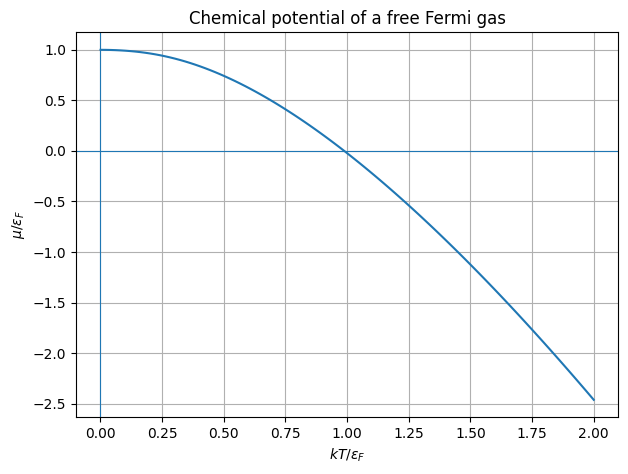

kT/epsilon_F = 0.0, mu/epsilon_F =  0.999999
kT/epsilon_F = 0.5, mu/epsilon_F =  0.743112
kT/epsilon_F = 1.0, mu/epsilon_F = -0.021461
kT/epsilon_F = 2.0, mu/epsilon_F = -2.461439


In [5]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import quad
from scipy.optimize import brentq
from scipy.special import expit


# Natural-unit choice
kB = 1.0
epsilon_F = 1.0


def N_ratio(mu, T):
    """
    Returns N_calculated / N
    using kB = epsilon_F = 1.
    """

    def integrand(epsilon):

        # Free-electron density of states divided by N
        g_over_N = (
            3.0
            / (2.0 * epsilon_F**1.5)
            * np.sqrt(epsilon)
        )

        # Fermi-Dirac occupation
        f_FD = expit(
            -(epsilon - mu) / (kB * T)
        )

        return g_over_N * f_FD

    value, error = quad(
        integrand,
        0.0,
        np.inf,
        epsabs=1e-10,
        epsrel=1e-10,
        limit=300
    )

    return value


def find_mu(T):
    """
    Find mu such that N_calculated / N = 1.
    """

    def equation(mu):
        return N_ratio(mu, T) - 1.0

    return brentq(
        equation,
        -20.0 * epsilon_F,
        3.0 * epsilon_F
    )


# Since kB = epsilon_F = 1,
# T numerically equals kT/epsilon_F.
min_T=0.001
T_values = np.linspace(min_T, 2.0, 100)

mu_values = np.array([
    find_mu(T)
    for T in T_values
])


plt.figure(figsize=(7, 5))

plt.plot(
    kB * T_values / epsilon_F,
    mu_values / epsilon_F
)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel(r"$kT/\epsilon_F$")
plt.ylabel(r"$\mu/\epsilon_F$")
plt.title("Chemical potential of a free Fermi gas")

plt.grid()

plt.show()


for T in [min_T, 0.5, 1.0, 2.0]:

    mu = find_mu(T)

    print(
        f"kT/epsilon_F = {kB*T/epsilon_F:3.1f}, "
        f"mu/epsilon_F = {mu/epsilon_F: .6f}"
    )

###(c)

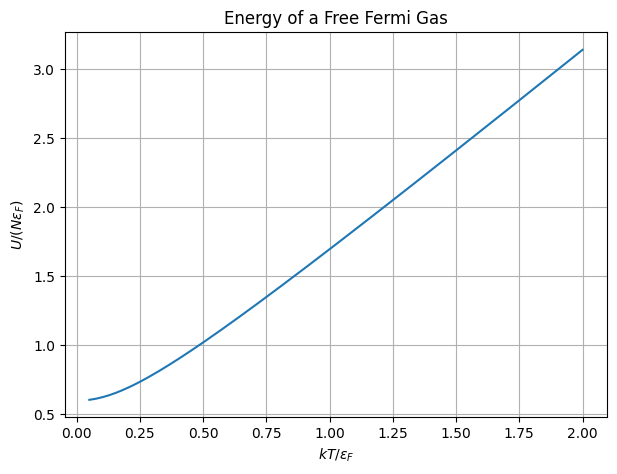

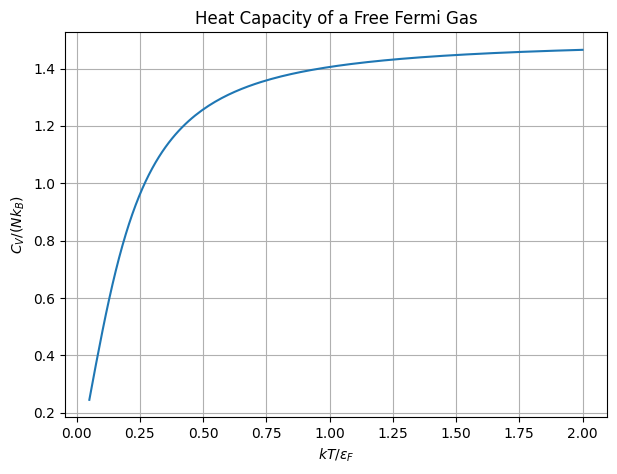

T = 0.1, mu =  0.991641, U/(N epsilon_F) =  0.624283
T = 0.5, mu =  0.743112, U/(N epsilon_F) =  1.021642
T = 1.0, mu = -0.021461, U/(N epsilon_F) =  1.696739
T = 2.0, mu = -2.461439, U/(N epsilon_F) =  3.140353


In [6]:


def U_ratio(mu, T):
    """
    Returns U / (N * epsilon_F).
    """

    def integrand(epsilon):
        g_over_N = (
            3.0
            / (2.0 * epsilon_F**1.5)
            * np.sqrt(epsilon)
        )

        f_FD = expit(
            -(epsilon - mu) / (kB * T)
        )

        return (
            epsilon
            * g_over_N
            * f_FD
            / epsilon_F
        )

    value, error = quad(
        integrand,
        0.0,
        np.inf,
        epsabs=1e-10,
        epsrel=1e-10,
        limit=300
    )

    return value


# Temperature range
T_values = np.linspace(0.05, 2.0, 150)

# Find mu(T)
mu_values = np.array([
    find_mu(T)
    for T in T_values
])

# Find U(T)
U_values = np.array([
    U_ratio(mu, T)
    for mu, T in zip(mu_values, T_values)
])


# Heat capacity:
# C_V / (N k_B)
#
# Since epsilon_F = k_B = 1,
# derivative of U/(N epsilon_F) with respect to T
# directly gives C_V/(N k_B).
Cv_values = np.gradient(
    U_values,
    T_values,
    edge_order=2
)


# ---- Plot U(T) ----

plt.figure(figsize=(7, 5))

plt.plot(T_values, U_values)

plt.xlabel(r"$kT/\epsilon_F$")
plt.ylabel(r"$U/(N\epsilon_F)$")
plt.title("Energy of a Free Fermi Gas")

plt.grid()
plt.show()


# ---- Plot C_V(T) ----

plt.figure(figsize=(7, 5))

plt.plot(T_values, Cv_values)

plt.xlabel(r"$kT/\epsilon_F$")
plt.ylabel(r"$C_V/(Nk_B)$")
plt.title("Heat Capacity of a Free Fermi Gas")

plt.grid()
plt.show()


# Some representative values
for T in [0.1, 0.5, 1.0, 2.0]:

    mu = find_mu(T)
    U = U_ratio(mu, T)

    print(
        f"T = {T:3.1f}, "
        f"mu = {mu: .6f}, "
        f"U/(N epsilon_F) = {U: .6f}"
    )